In [413]:
import pandas as pd
import numpy as np


In [414]:
df=pd.read_csv('Traffic_Data_Gov.csv')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print('\n--- COLUMN NAMES ---')
print(df.columns.tolist())
df.head()

Rows: 273,913
Columns: 27

--- COLUMN NAMES ---
['the_geom', 'cartodb_id', 'the_geom_webmercator', 'record_id', 'station_key', 'station_id', 'traffic_direction_seq', 'traffic_direction_name', 'cardinal_direction_seq', 'cardinal_direction_name', 'classification_seq', 'classification_type', 'count_type', 'year', 'period', 'partial_year', 'latest_date', 'traffic_count', 'data_start_date', 'data_end_date', 'data_duration', 'data_availability', 'data_reliability', 'data_quality_indicator', 'publish', 'md5', 'updated_on']


C:\Users\vilas\AppData\Local\Temp\ipykernel_4524\2752394424.py:1: DtypeWarning: Columns (16,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Traffic_Data_Gov.csv')


,the_geom,cartodb_id,the_geom_webmercator,record_id,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,...,traffic_count,data_start_date,data_end_date,data_duration,data_availability,data_reliability,data_quality_indicator,publish,md5,updated_on
0,NaN,670946,NaN,NaN,55318,02015,2,PRESCRIBED AND COUNTER,9,BOTH,...,39273,NaN,NaN,NaN,-1,-1,0,1,2c3a9b9bf222b4b98d5da5b20455e378,2018-12-14 05:33:24.64657+00
1,NaN,670947,NaN,NaN,15252005,6157,0,COUNTER,5,SOUTH,...,705,NaN,NaN,NaN,1,92,0,1,80c733285025af031a4fffaa89f004db,2022-02-04 09:44:28.431958+00
2,NaN,670948,NaN,NaN,57462,83011,0,COUNTER,5,SOUTH,...,1722,NaN,NaN,NaN,10,77,0,1,f93f7c9eb82be6744ae1fd7b2716ef55,2020-09-03 01:24:31.45111+00
3,NaN,670949,NaN,NaN,58875,F3FWY006,2,PRESCRIBED AND COUNTER,9,BOTH,...,2178,NaN,NaN,NaN,-1,-1,0,1,b5cc8afd807d718fa40f2b7872458136,2018-07-09 03:45:51.087472+00
4,NaN,670950,NaN,NaN,56892,34029,0,COUNTER,5,SOUTH,...,7541,NaN,NaN,NaN,-1,-1,0,1,eb6c56f804a90c58d627524cd313fed5,2018-01-09 22:39:10.806238+00


In [415]:
df.dtypes

the_geom                   float64
cartodb_id                   int64
the_geom_webmercator       float64
record_id                  float64
station_key                  int64
station_id                  object
traffic_direction_seq        int64
traffic_direction_name      object
cardinal_direction_seq       int64
cardinal_direction_name     object
classification_seq           int64
classification_type         object
count_type                  object
year                         int64
period                      object
partial_year                  bool
latest_date                 object
traffic_count                int64
data_start_date             object
data_end_date               object
data_duration              float64
data_availability            int64
data_reliability             int64
data_quality_indicator       int64
publish                      int64
md5                         object
updated_on                  object
dtype: object

In [416]:
df.isna().sum()

the_geom                   273913
cartodb_id                      0
the_geom_webmercator       273913
record_id                  273913
station_key                     0
station_id                      0
traffic_direction_seq           0
traffic_direction_name          0
cardinal_direction_seq          0
cardinal_direction_name         0
classification_seq              0
classification_type             0
count_type                      0
year                            0
period                          0
partial_year                    0
latest_date                260590
traffic_count                   0
data_start_date            207663
data_end_date              207663
data_duration              207663
data_availability               0
data_reliability                0
data_quality_indicator          0
publish                         0
md5                             0
updated_on                 153072
dtype: int64

In [417]:
col = [
    'the_geom', 'the_geom_webmercator', 'record_id',
    'latest_date', 'data_start_date', 'data_end_date',
    'data_duration', 'updated_on', 'md5', 'count_type',
    'publish', 'data_quality_indicator', 'cartodb_id'
]
df.drop(columns=col,inplace=True)

In [418]:
df.shape

(273913, 14)

In [419]:
df.isna().sum()

station_key                0
station_id                 0
traffic_direction_seq      0
traffic_direction_name     0
cardinal_direction_seq     0
cardinal_direction_name    0
classification_seq         0
classification_type        0
year                       0
period                     0
partial_year               0
traffic_count              0
data_availability          0
data_reliability           0
dtype: int64

In [420]:
cat_cols = ['traffic_direction_name', 'cardinal_direction_name', 
            'classification_type', 'period', 'partial_year']
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(f"Total unique: {df[col].nunique()}")


--- traffic_direction_name ---
traffic_direction_name
PRESCRIBED                97612
COUNTER                   95648
PRESCRIBED AND COUNTER    80653
Name: count, dtype: int64
Total unique: 3

--- cardinal_direction_name ---
cardinal_direction_name
SOUTH                        58537
NORTH                        58379
WEST                         38480
EAST                         37864
NORTHBOUND AND SOUTHBOUND    32173
BOTH                         28072
EASTBOUND AND WESTBOUND      20408
Name: count, dtype: int64
Total unique: 7

--- classification_type ---
classification_type
UNCLASSIFIED      76357
LIGHT VEHICLES    66111
HEAVY VEHICLES    66037
ALL VEHICLES      65408
Name: count, dtype: int64
Total unique: 4

--- period ---
period
ALL DAYS           42266
OFF PEAK           42251
WEEKDAYS           42234
PM PEAK            42229
AM PEAK            42213
WEEKENDS           42003
PUBLIC HOLIDAYS    20645
SCHOOL HOLIDAYS       72
Name: count, dtype: int64
Total unique: 8

--- partia

In [421]:
df.head()

,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,classification_seq,classification_type,year,period,partial_year,traffic_count,data_availability,data_reliability
0,55318,02015,2,PRESCRIBED AND COUNTER,9,BOTH,0,UNCLASSIFIED,2018,WEEKDAYS,False,39273,-1,-1
1,15252005,6157,0,COUNTER,5,SOUTH,3,HEAVY VEHICLES,2022,ALL DAYS,False,705,1,92
2,57462,83011,0,COUNTER,5,SOUTH,3,HEAVY VEHICLES,2020,ALL DAYS,False,1722,10,77
3,58875,F3FWY006,2,PRESCRIBED AND COUNTER,9,BOTH,3,HEAVY VEHICLES,2018,PM PEAK,False,2178,-1,-1
4,56892,34029,0,COUNTER,5,SOUTH,0,UNCLASSIFIED,2016,WEEKDAYS,True,7541,-1,-1


In [422]:
df.dtypes

station_key                 int64
station_id                 object
traffic_direction_seq       int64
traffic_direction_name     object
cardinal_direction_seq      int64
cardinal_direction_name    object
classification_seq          int64
classification_type        object
year                        int64
period                     object
partial_year                 bool
traffic_count               int64
data_availability           int64
data_reliability            int64
dtype: object

In [423]:
df['data_availability'].value_counts()

data_availability
-1     176337
 2       6262
 1       5014
 3       4106
 0       3619
        ...  
 58       570
 40       570
 49       561
 9        560
 82       517
Name: count, Length: 102, dtype: int64

In [424]:
df['data_reliability'].value_counts()

data_reliability
-1      176337
 100     15810
 96       6490
 95       6076
 97       5731
         ...  
 1           5
 4           5
 11          4
 2           3
 0           1
Name: count, Length: 102, dtype: int64

In [425]:
df['data_availability']=df['data_availability'].replace(-1,np.nan)
df['data_reliability']=df['data_reliability'].replace(-1,np.nan)

In [426]:
df['data_availability'].fillna(df['data_availability'].median(),inplace=True)
df['data_reliability'].fillna(df['data_reliability'].median(),  inplace=True)


C:\Users\vilas\AppData\Local\Temp\ipykernel_4524\2136999538.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['data_availability'].fillna(df['data_availability'].median(),inplace=True)
C:\Users\vilas\AppData\Local\Temp\ipykernel_4524\2136999538.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [427]:
print(f"\ndata_availability nulls : {df['data_availability'].isnull().sum()}")
print(f"data_reliability nulls  : {df['data_reliability'].isnull().sum()}")


data_availability nulls : 0
data_reliability nulls  : 0


In [428]:
print(df['traffic_count'].value_counts())

traffic_count
36        290
39        278
34        278
47        269
41        267
         ... 
109213      1
127753      1
30295       1
67941       1
39742       1
Name: count, Length: 40594, dtype: int64


In [429]:
print(df[df['traffic_count'] < 0])

Empty DataFrame
Columns: [station_key, station_id, traffic_direction_seq, traffic_direction_name, cardinal_direction_seq, cardinal_direction_name, classification_seq, classification_type, year, period, partial_year, traffic_count, data_availability, data_reliability]
Index: []


In [430]:
df

,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,classification_seq,classification_type,year,period,partial_year,traffic_count,data_availability,data_reliability
0,55318,02015,2,PRESCRIBED AND COUNTER,9,BOTH,0,UNCLASSIFIED,2018,WEEKDAYS,False,39273,37.0,93.0
1,15252005,6157,0,COUNTER,5,SOUTH,3,HEAVY VEHICLES,2022,ALL DAYS,False,705,1.0,92.0
2,57462,83011,0,COUNTER,5,SOUTH,3,HEAVY VEHICLES,2020,ALL DAYS,False,1722,10.0,77.0
3,58875,F3FWY006,2,PRESCRIBED AND COUNTER,9,BOTH,3,HEAVY VEHICLES,2018,PM PEAK,False,2178,37.0,93.0
4,56892,34029,0,COUNTER,5,SOUTH,0,UNCLASSIFIED,2016,WEEKDAYS,True,7541,37.0,93.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273908,74998002,T6189W,2,PRESCRIBED AND COUNTER,10,BOTH,2,LIGHT VEHICLES,2025,AM PEAK,False,1926,37.0,93.0
273909,15828018,T0494,2,PRESCRIBED AND COUNTER,9,BOTH,1,ALL VEHICLES,2025,WEEKENDS,False,236,37.0,93.0
273910,15175635,6124,2,PRESCRIBED AND COUNTER,9,BOTH,3,HEAVY VEHICLES,2025,PM PEAK,False,325,37.0,93.0
273911,74612001,T6132W,0,COUNTER,3,EAST,1,ALL VEHICLES,2025,AM PEAK,False,192,37.0,93.0


In [431]:
cat_cols = [
    'traffic_direction_name',
    'cardinal_direction_name',
    'classification_type',
    'period'
]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

print(f"\n--- year ---")
print(f"Min : {df['year'].min()}")
print(f"Max : {df['year'].max()}")

print(f"\n--- traffic_count ---")
print(df['traffic_count'].describe())


--- traffic_direction_name ---
traffic_direction_name
PRESCRIBED                97612
COUNTER                   95648
PRESCRIBED AND COUNTER    80653
Name: count, dtype: int64

--- cardinal_direction_name ---
cardinal_direction_name
SOUTH                        58537
NORTH                        58379
WEST                         38480
EAST                         37864
NORTHBOUND AND SOUTHBOUND    32173
BOTH                         28072
EASTBOUND AND WESTBOUND      20408
Name: count, dtype: int64

--- classification_type ---
classification_type
UNCLASSIFIED      76357
LIGHT VEHICLES    66111
HEAVY VEHICLES    66037
ALL VEHICLES      65408
Name: count, dtype: int64

--- period ---
period
ALL DAYS           42266
OFF PEAK           42251
WEEKDAYS           42234
PM PEAK            42229
AM PEAK            42213
WEEKENDS           42003
PUBLIC HOLIDAYS    20645
SCHOOL HOLIDAYS       72
Name: count, dtype: int64

--- year ---
Min : 2006
Max : 2026

--- traffic_count ---
count    273913.

In [432]:
df['year'].value_counts().sort_index()

year
2006    17052
2007    12706
2008    13623
2009    16596
2010    23333
2011    17980
2012    11365
2013     8231
2014     7166
2015    14100
2016    13323
2017    15617
2018    15886
2019    12538
2020    12000
2021     9934
2022     7744
2023     6223
2024    12058
2025    17834
2026     8604
Name: count, dtype: int64

In [433]:
df.drop(df[df['year']==2026].index,inplace=True)

In [434]:
df['year'].value_counts().sort_index()

year
2006    17052
2007    12706
2008    13623
2009    16596
2010    23333
2011    17980
2012    11365
2013     8231
2014     7166
2015    14100
2016    13323
2017    15617
2018    15886
2019    12538
2020    12000
2021     9934
2022     7744
2023     6223
2024    12058
2025    17834
Name: count, dtype: int64

In [435]:
df.drop(df[df['period']=='SCHOOL HOLIDAYS'].index,inplace=True)
df['period'].value_counts().sort_values()

period
PUBLIC HOLIDAYS    20591
WEEKENDS           40607
AM PEAK            40793
PM PEAK            40809
WEEKDAYS           40814
OFF PEAK           40831
ALL DAYS           40846
Name: count, dtype: int64

In [436]:
df

,station_key,station_id,traffic_direction_seq,traffic_direction_name,cardinal_direction_seq,cardinal_direction_name,classification_seq,classification_type,year,period,partial_year,traffic_count,data_availability,data_reliability
0,55318,02015,2,PRESCRIBED AND COUNTER,9,BOTH,0,UNCLASSIFIED,2018,WEEKDAYS,False,39273,37.0,93.0
1,15252005,6157,0,COUNTER,5,SOUTH,3,HEAVY VEHICLES,2022,ALL DAYS,False,705,1.0,92.0
2,57462,83011,0,COUNTER,5,SOUTH,3,HEAVY VEHICLES,2020,ALL DAYS,False,1722,10.0,77.0
3,58875,F3FWY006,2,PRESCRIBED AND COUNTER,9,BOTH,3,HEAVY VEHICLES,2018,PM PEAK,False,2178,37.0,93.0
4,56892,34029,0,COUNTER,5,SOUTH,0,UNCLASSIFIED,2016,WEEKDAYS,True,7541,37.0,93.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273908,74998002,T6189W,2,PRESCRIBED AND COUNTER,10,BOTH,2,LIGHT VEHICLES,2025,AM PEAK,False,1926,37.0,93.0
273909,15828018,T0494,2,PRESCRIBED AND COUNTER,9,BOTH,1,ALL VEHICLES,2025,WEEKENDS,False,236,37.0,93.0
273910,15175635,6124,2,PRESCRIBED AND COUNTER,9,BOTH,3,HEAVY VEHICLES,2025,PM PEAK,False,325,37.0,93.0
273911,74612001,T6132W,0,COUNTER,3,EAST,1,ALL VEHICLES,2025,AM PEAK,False,192,37.0,93.0


In [437]:
df['partial_year'].value_counts()

partial_year
False    251968
True      13323
Name: count, dtype: int64

In [438]:
drop_cols = [
    'traffic_direction_seq',  # duplicate of traffic_direction_name
    'cardinal_direction_seq', # duplicate of cardinal_direction_name
    'classification_seq',     # duplicate of classification_type
    'partial_year',           # 95% same values
    'station_key',            # duplicate of station_id
]
df.drop(columns=drop_cols,inplace=True)
print('number of columns : ',df.shape[1])
print('number of rows : ',df.shape[0])

number of columns :  9
number of rows :  265291


In [439]:
df.columns.tolist()

['station_id',
 'traffic_direction_name',
 'cardinal_direction_name',
 'classification_type',
 'year',
 'period',
 'traffic_count',
 'data_availability',
 'data_reliability']

In [440]:
df

,station_id,traffic_direction_name,cardinal_direction_name,classification_type,year,period,traffic_count,data_availability,data_reliability
0,02015,PRESCRIBED AND COUNTER,BOTH,UNCLASSIFIED,2018,WEEKDAYS,39273,37.0,93.0
1,6157,COUNTER,SOUTH,HEAVY VEHICLES,2022,ALL DAYS,705,1.0,92.0
2,83011,COUNTER,SOUTH,HEAVY VEHICLES,2020,ALL DAYS,1722,10.0,77.0
3,F3FWY006,PRESCRIBED AND COUNTER,BOTH,HEAVY VEHICLES,2018,PM PEAK,2178,37.0,93.0
4,34029,COUNTER,SOUTH,UNCLASSIFIED,2016,WEEKDAYS,7541,37.0,93.0
...,...,...,...,...,...,...,...,...,...
273908,T6189W,PRESCRIBED AND COUNTER,BOTH,LIGHT VEHICLES,2025,AM PEAK,1926,37.0,93.0
273909,T0494,PRESCRIBED AND COUNTER,BOTH,ALL VEHICLES,2025,WEEKENDS,236,37.0,93.0
273910,6124,PRESCRIBED AND COUNTER,BOTH,HEAVY VEHICLES,2025,PM PEAK,325,37.0,93.0
273911,T6132W,COUNTER,EAST,ALL VEHICLES,2025,AM PEAK,192,37.0,93.0


In [441]:
df.dtypes

station_id                  object
traffic_direction_name      object
cardinal_direction_name     object
classification_type         object
year                         int64
period                      object
traffic_count                int64
data_availability          float64
data_reliability           float64
dtype: object

# ENCODING

In [442]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
encode_cols = [
    'station_id',
    'traffic_direction_name',
    'cardinal_direction_name',
    'classification_type',
    'period'
]
for i in encode_cols:
    df[i+'_encoded']=le.fit_transform(df[i].astype(str))
    print(f"✅ {i} → {i}_encoded")
    

✅ station_id → station_id_encoded
✅ traffic_direction_name → traffic_direction_name_encoded
✅ cardinal_direction_name → cardinal_direction_name_encoded
✅ classification_type → classification_type_encoded
✅ period → period_encoded


In [443]:
df

,station_id,traffic_direction_name,cardinal_direction_name,classification_type,year,period,traffic_count,data_availability,data_reliability,station_id_encoded,traffic_direction_name_encoded,cardinal_direction_name_encoded,classification_type_encoded,period_encoded
0,02015,PRESCRIBED AND COUNTER,BOTH,UNCLASSIFIED,2018,WEEKDAYS,39273,37.0,93.0,7,2,0,3,5
1,6157,COUNTER,SOUTH,HEAVY VEHICLES,2022,ALL DAYS,705,1.0,92.0,869,0,5,1,0
2,83011,COUNTER,SOUTH,HEAVY VEHICLES,2020,ALL DAYS,1722,10.0,77.0,1061,0,5,1,0
3,F3FWY006,PRESCRIBED AND COUNTER,BOTH,HEAVY VEHICLES,2018,PM PEAK,2178,37.0,93.0,1789,2,0,1,3
4,34029,COUNTER,SOUTH,UNCLASSIFIED,2016,WEEKDAYS,7541,37.0,93.0,682,0,5,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273908,T6189W,PRESCRIBED AND COUNTER,BOTH,LIGHT VEHICLES,2025,AM PEAK,1926,37.0,93.0,1920,2,0,2,1
273909,T0494,PRESCRIBED AND COUNTER,BOTH,ALL VEHICLES,2025,WEEKENDS,236,37.0,93.0,1868,2,0,0,6
273910,6124,PRESCRIBED AND COUNTER,BOTH,HEAVY VEHICLES,2025,PM PEAK,325,37.0,93.0,844,2,0,1,3
273911,T6132W,COUNTER,EAST,ALL VEHICLES,2025,AM PEAK,192,37.0,93.0,1885,0,1,0,1


In [444]:
print(f'Total columns now: {df.shape[1]}')
df.head(3)

Total columns now: 14


,station_id,traffic_direction_name,cardinal_direction_name,classification_type,year,period,traffic_count,data_availability,data_reliability,station_id_encoded,traffic_direction_name_encoded,cardinal_direction_name_encoded,classification_type_encoded,period_encoded
0,02015,PRESCRIBED AND COUNTER,BOTH,UNCLASSIFIED,2018,WEEKDAYS,39273,37.0,93.0,7,2,0,3,5
1,6157,COUNTER,SOUTH,HEAVY VEHICLES,2022,ALL DAYS,705,1.0,92.0,869,0,5,1,0
2,83011,COUNTER,SOUTH,HEAVY VEHICLES,2020,ALL DAYS,1722,10.0,77.0,1061,0,5,1,0


In [445]:
df['period'].value_counts()

period
ALL DAYS           40846
OFF PEAK           40831
WEEKDAYS           40814
PM PEAK            40809
AM PEAK            40793
WEEKENDS           40607
PUBLIC HOLIDAYS    20591
Name: count, dtype: int64

In [446]:
df['is_peak'] = df['period'].str.contains('PEAK').astype(int)

df['is_weekend'] = df['period'].str.contains('WEEKEND').astype(int)


df['is_holiday'] = df['period'].str.contains('HOLIDAY').astype(int)


df['is_both_directions'] = df['traffic_direction_name'].str.contains('AND').astype(int)


df['is_heavy'] = (df['classification_type'] == 'HEAVY VEHICLES').astype(int)


df['decade'] = (df['year'] // 10) * 10

print(f"✅ Total columns now: {df.shape[1]}")
print("\nNew features sample:")
df[['period','is_peak','is_weekend','is_holiday',
          'is_both_directions','is_heavy','decade']].head(5)

✅ Total columns now: 20

New features sample:


,period,is_peak,is_weekend,is_holiday,is_both_directions,is_heavy,decade
0,WEEKDAYS,0,0,0,1,0,2010
1,ALL DAYS,0,0,0,0,1,2020
2,ALL DAYS,0,0,0,0,1,2020
3,PM PEAK,1,0,0,1,1,2010
4,WEEKDAYS,0,0,0,0,0,2010


C:\Users\vilas\AppData\Local\Temp\ipykernel_4524\3096629558.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(class_avg.index, rotation=15, ha='right')


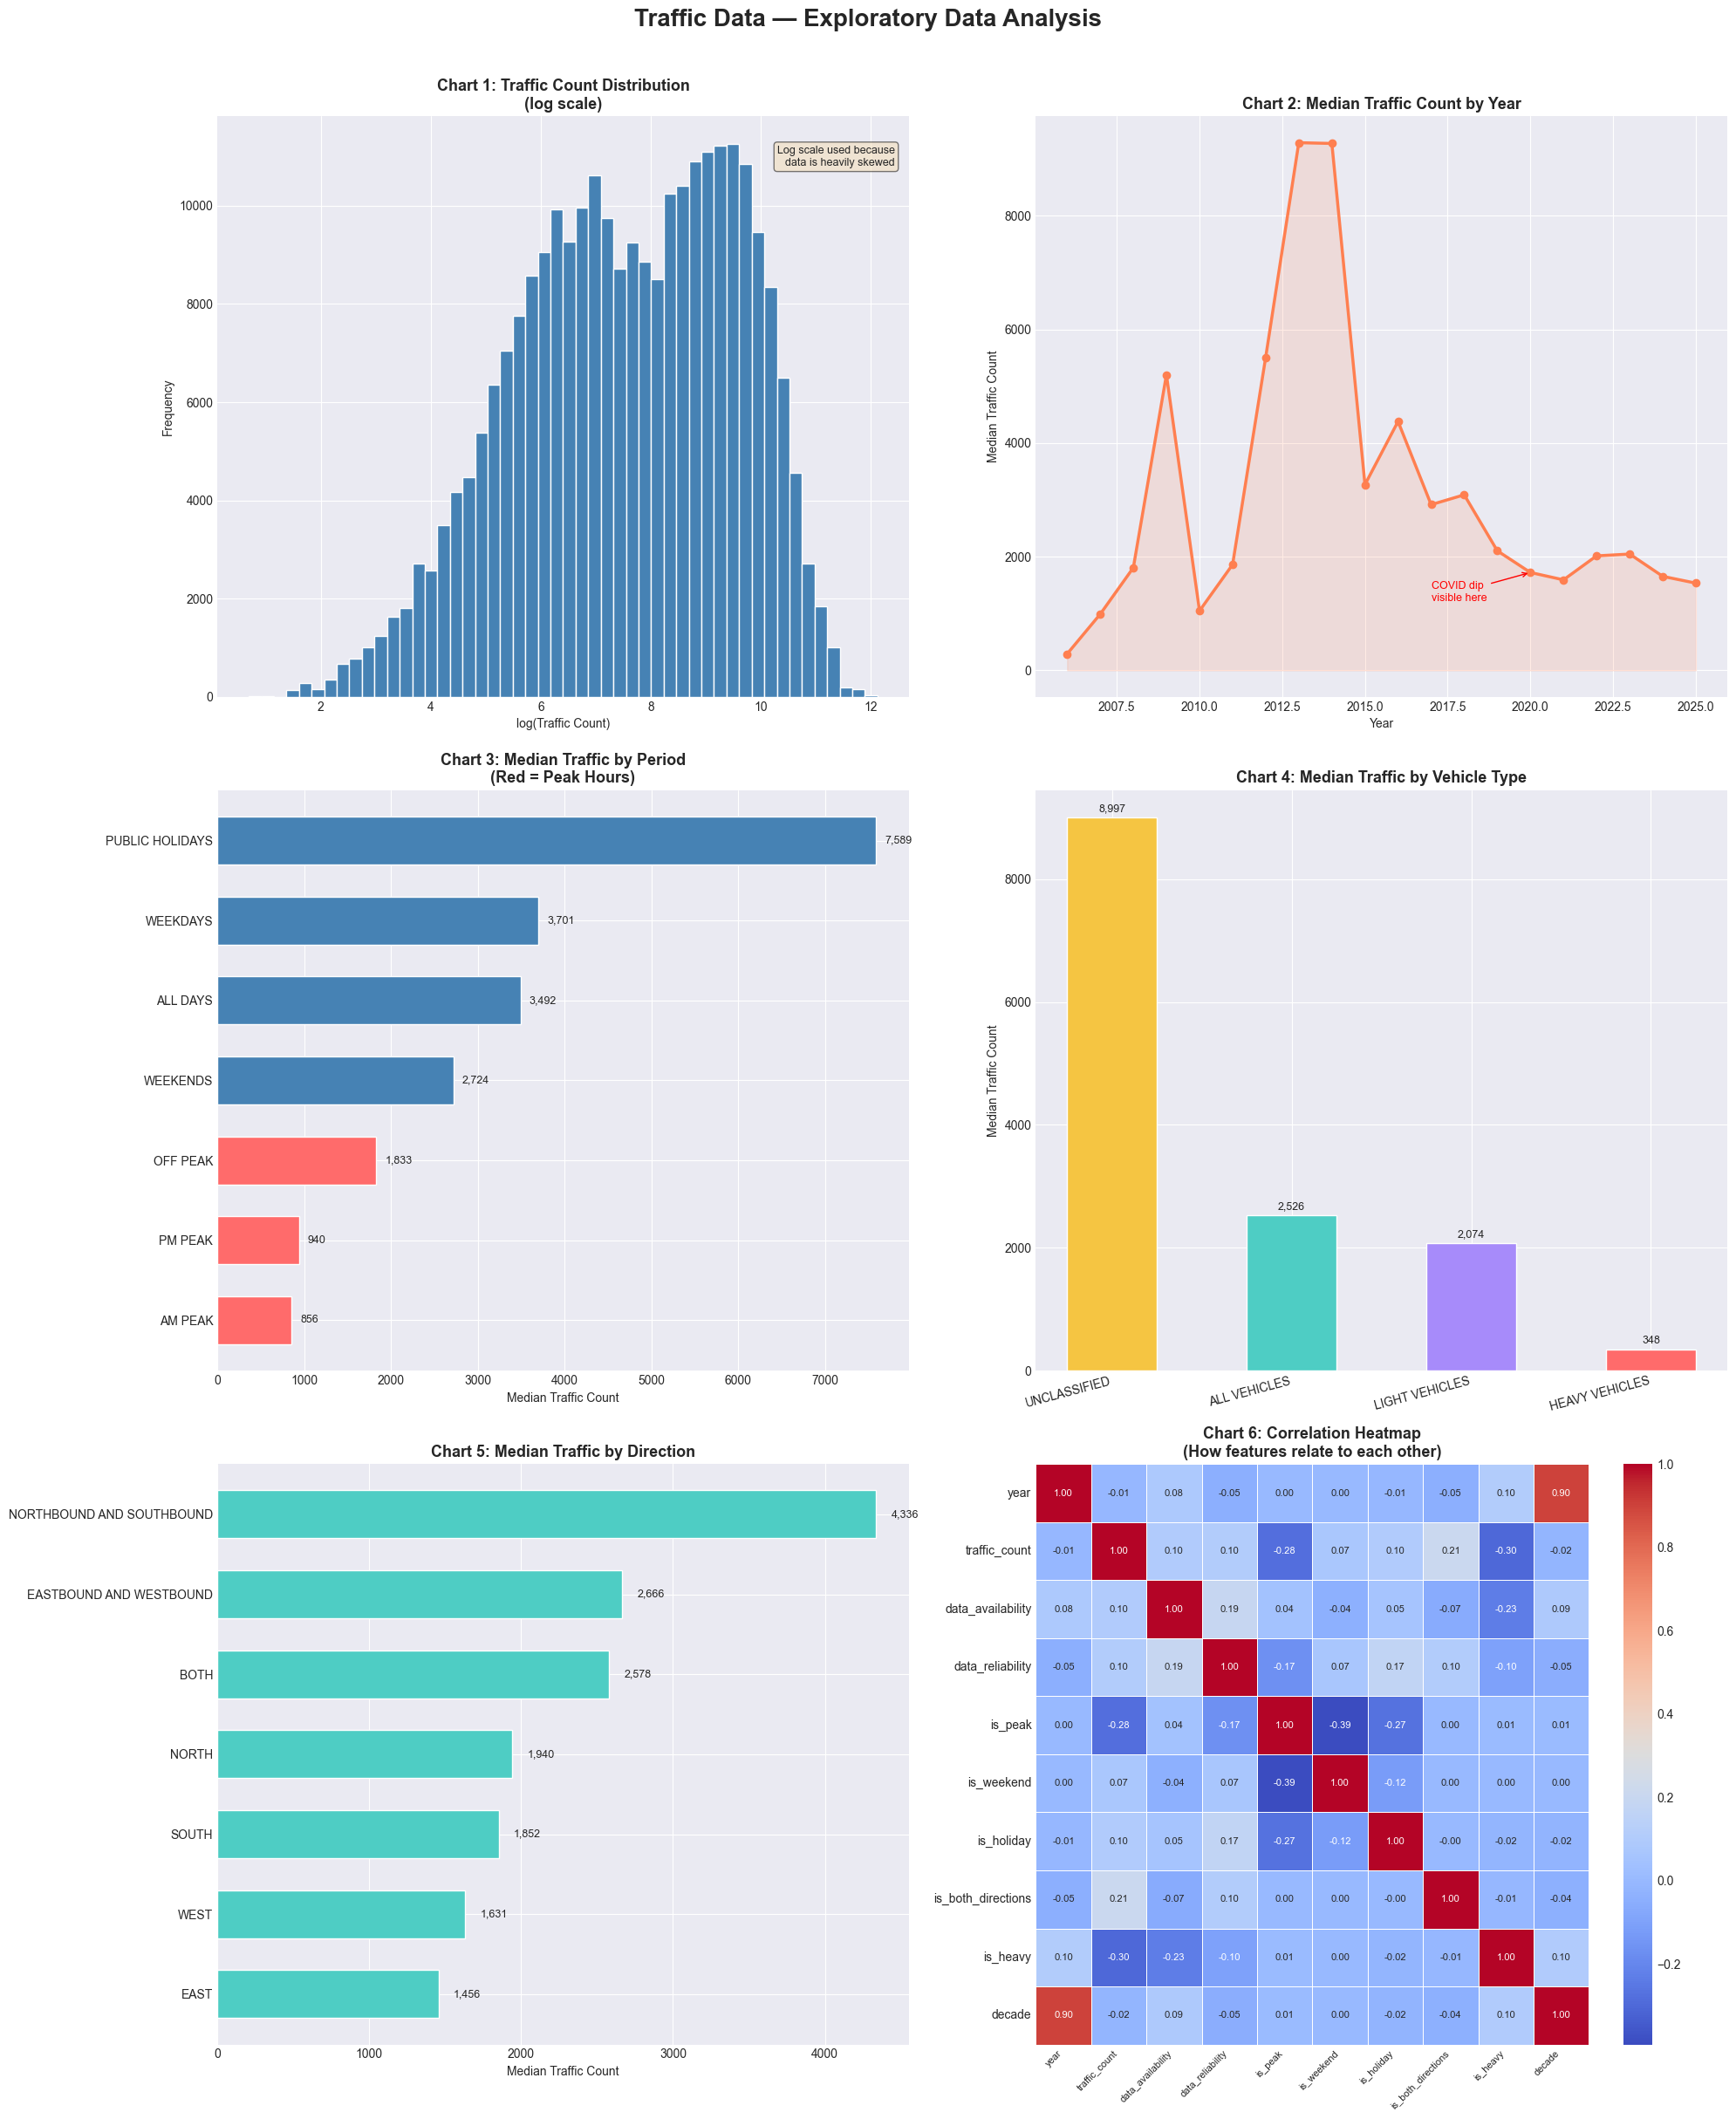

✅ All 6 charts saved as eda_charts.png


In [447]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dark professional style
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 24))
fig.suptitle('Traffic Data — Exploratory Data Analysis', 
             fontsize=20, fontweight='bold', y=1.01)

# ─────────────────────────────
# Chart 1: Traffic Count Distribution
# ─────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
ax1.hist(np.log1p(df['traffic_count']), 
         bins=50, color='steelblue', edgecolor='white')
ax1.set_title('Chart 1: Traffic Count Distribution\n(log scale)', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('log(Traffic Count)')
ax1.set_ylabel('Frequency')
ax1.annotate('Log scale used because\ndata is heavily skewed', 
             xy=(0.98, 0.95), xycoords='axes fraction',
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ─────────────────────────────
# Chart 2: Traffic by Year
# ─────────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
year_avg = df.groupby('year')['traffic_count'].median()
ax2.plot(year_avg.index, year_avg.values, 
         color='coral', linewidth=2.5, marker='o', markersize=6)
ax2.fill_between(year_avg.index, year_avg.values, 
                 alpha=0.15, color='coral')
ax2.set_title('Chart 2: Median Traffic Count by Year', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Median Traffic Count')
ax2.annotate('COVID dip\nvisible here', 
             xy=(2020, year_avg[2020]),
             xytext=(2017, year_avg[2020]-500),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')

# ─────────────────────────────
# Chart 3: Traffic by Period
# ─────────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
period_avg = df.groupby('period')['traffic_count'].median().sort_values(ascending=True)
colors = ['#ff6b6b' if 'PEAK' in p else 'steelblue' for p in period_avg.index]
bars = ax3.barh(period_avg.index, period_avg.values, 
                color=colors, edgecolor='white', height=0.6)
ax3.set_title('Chart 3: Median Traffic by Period\n(Red = Peak Hours)', 
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Median Traffic Count')
for bar, val in zip(bars, period_avg.values):
    ax3.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=9)

# ─────────────────────────────
# Chart 4: Traffic by Vehicle Type
# ─────────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
class_avg = df.groupby('classification_type')['traffic_count'].median().sort_values(ascending=False)
bar_colors = ['#f5c542', '#4ecdc4', '#a78bfa', '#ff6b6b']
bars = ax4.bar(class_avg.index, class_avg.values,
               color=bar_colors, edgecolor='white', width=0.5)
ax4.set_title('Chart 4: Median Traffic by Vehicle Type', 
              fontsize=13, fontweight='bold')
ax4.set_ylabel('Median Traffic Count')
ax4.set_xticklabels(class_avg.index, rotation=15, ha='right')
for bar, val in zip(bars, class_avg.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,.0f}', ha='center', fontsize=9)

# ─────────────────────────────
# Chart 5: Traffic by Direction
# ─────────────────────────────
ax5 = fig.add_subplot(3, 2, 5)
dir_avg = df.groupby('cardinal_direction_name')['traffic_count'].median().sort_values(ascending=True)
bar_colors2 = ['#4ecdc4'] * len(dir_avg)
bars = ax5.barh(dir_avg.index, dir_avg.values,
                color=bar_colors2, edgecolor='white', height=0.6)
ax5.set_title('Chart 5: Median Traffic by Direction', 
              fontsize=13, fontweight='bold')
ax5.set_xlabel('Median Traffic Count')
for bar, val in zip(bars, dir_avg.values):
    ax5.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=9)

# ─────────────────────────────
# Chart 6: Correlation Heatmap
# ─────────────────────────────
ax6 = fig.add_subplot(3, 2, 6)
num_cols = ['year', 'traffic_count', 'data_availability',
            'data_reliability', 'is_peak', 'is_weekend',
            'is_holiday', 'is_both_directions', 'is_heavy', 'decade']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax6, linewidths=0.5, annot_kws={'size': 8})
ax6.set_title('Chart 6: Correlation Heatmap\n(How features relate to each other)',
              fontsize=13, fontweight='bold')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All 6 charts saved as eda_charts.png")


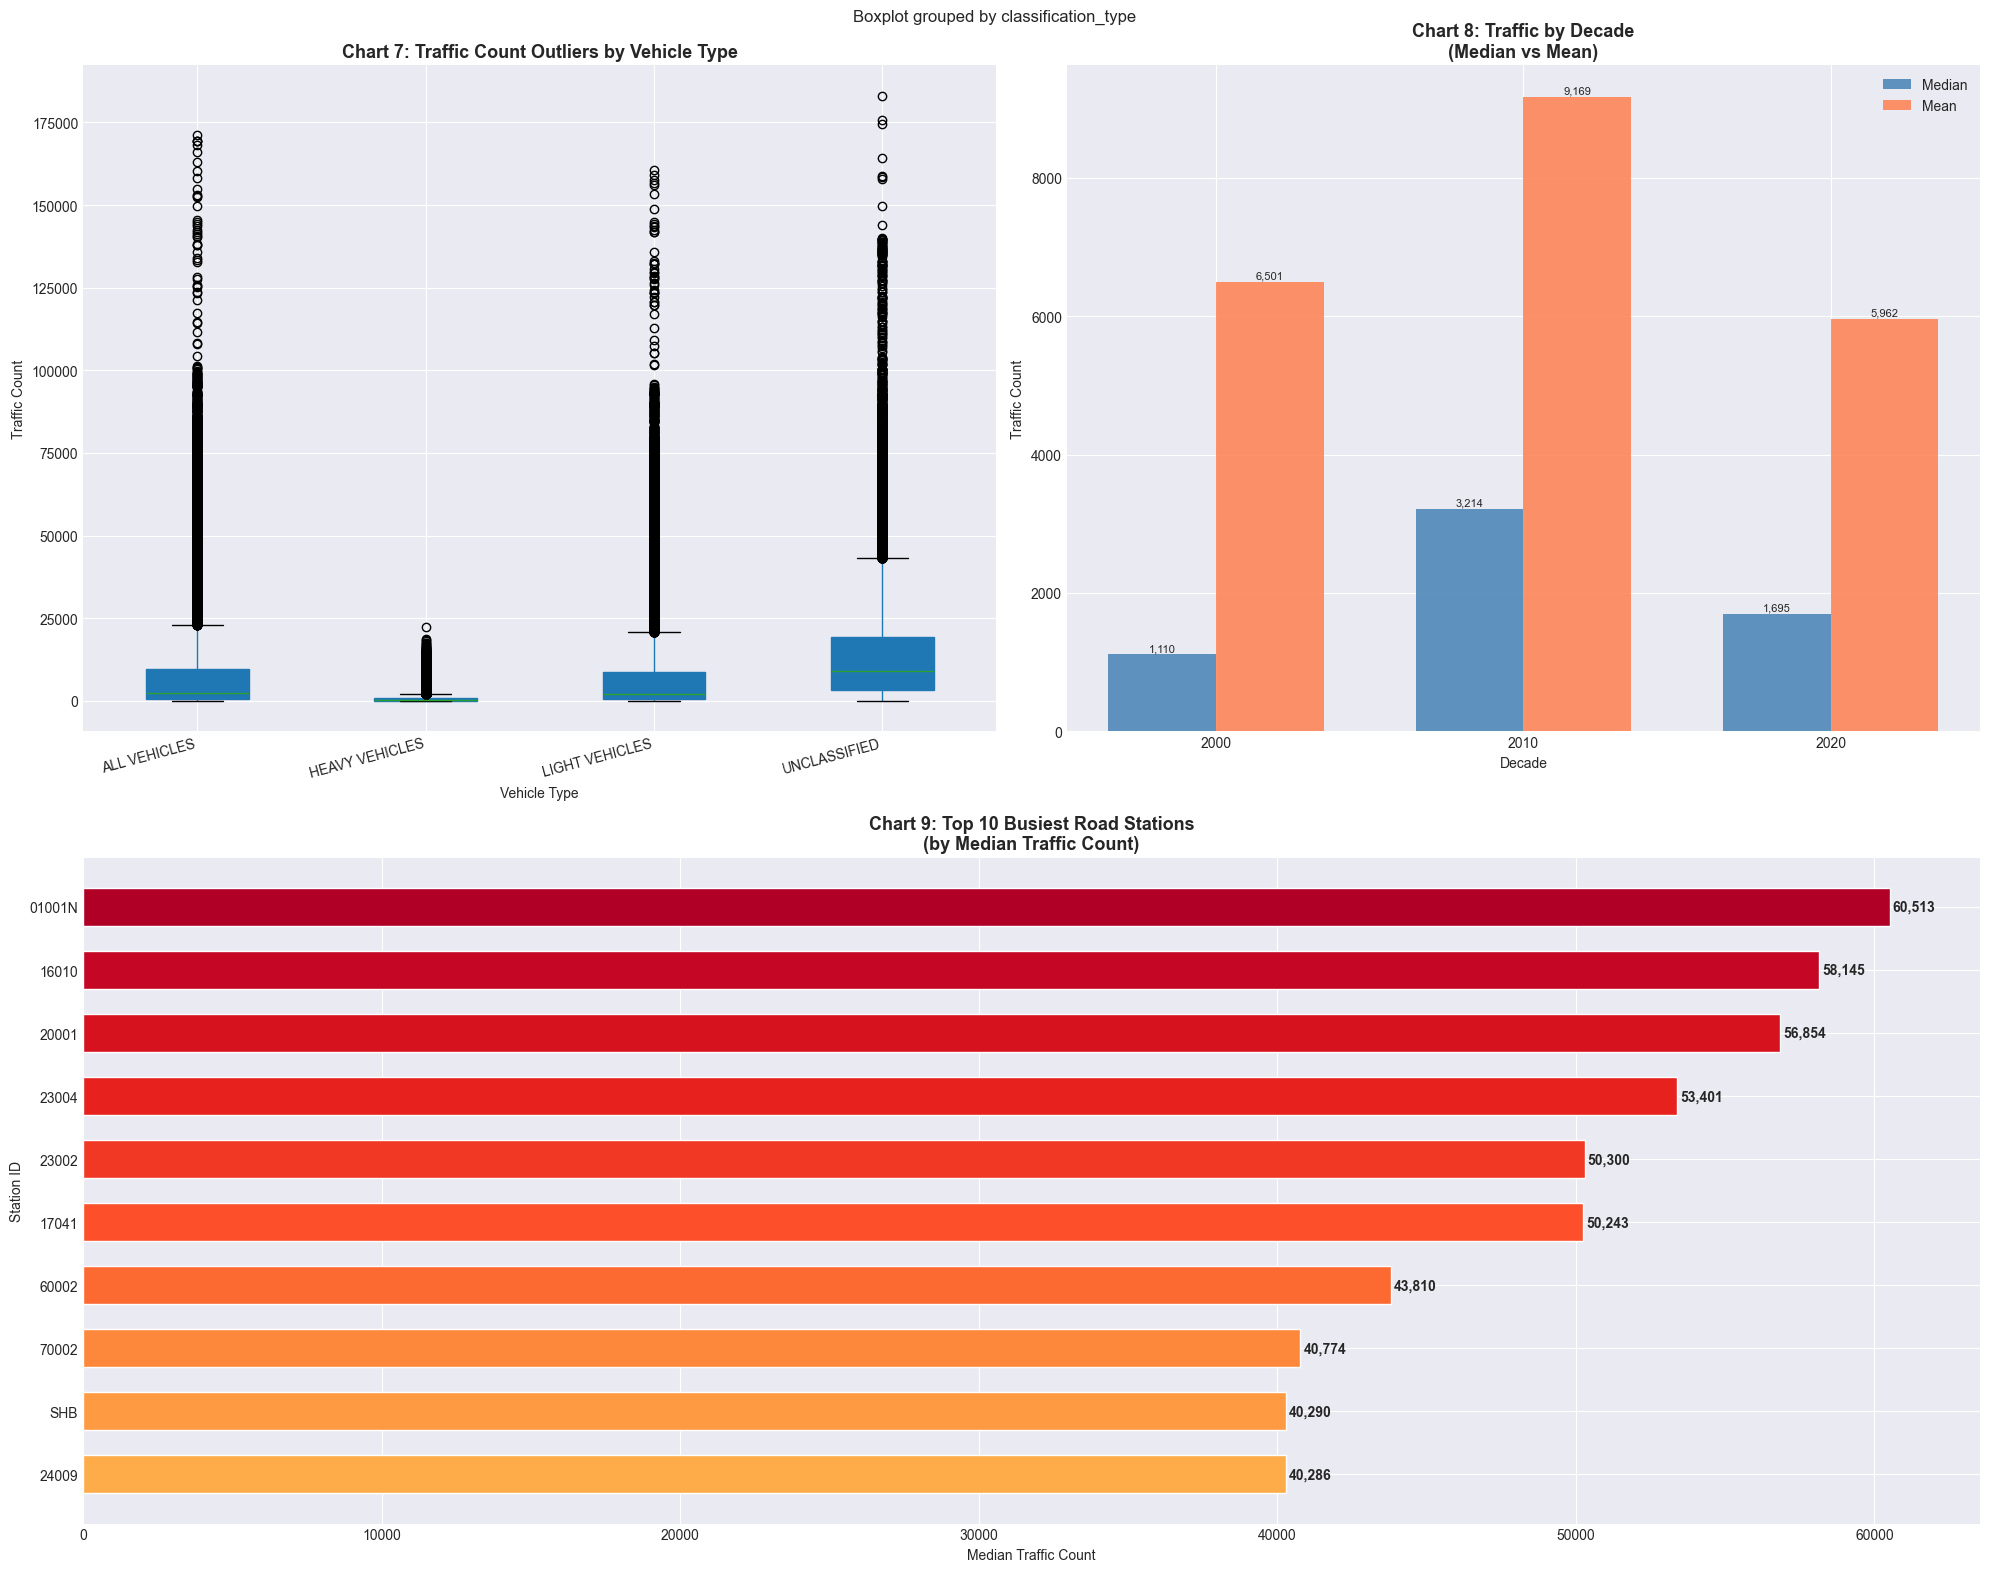

✅ Charts 7, 8, 9 saved as eda_charts2.png


In [448]:
fig2 = plt.figure(figsize=(20, 16))
fig2.suptitle('Traffic Data — Additional Analysis', 
              fontsize=20, fontweight='bold')

# ─────────────────────────────
# Chart 7: Boxplot — Outliers
# ─────────────────────────────
ax7 = fig2.add_subplot(2, 2, 1)
df.boxplot(column='traffic_count', 
                 by='classification_type',
                 ax=ax7, 
                 patch_artist=True)
ax7.set_title('Chart 7: Traffic Count Outliers\nby Vehicle Type', 
              fontsize=13, fontweight='bold')
ax7.set_xlabel('Vehicle Type')
ax7.set_ylabel('Traffic Count')
ax7.set_xticklabels(ax7.get_xticklabels(), 
                    rotation=15, ha='right')
plt.sca(ax7)
plt.title('Chart 7: Traffic Count Outliers by Vehicle Type',
          fontsize=13, fontweight='bold')

# ─────────────────────────────
# Chart 8: Traffic by Decade
# ─────────────────────────────
ax8 = fig2.add_subplot(2, 2, 2)
decade_avg = df.groupby('decade')['traffic_count'].agg(['median','mean'])
x = np.arange(len(decade_avg))
width = 0.35
ax8.bar(x - width/2, decade_avg['median'], width,
        label='Median', color='steelblue', alpha=0.85)
ax8.bar(x + width/2, decade_avg['mean'], width,
        label='Mean', color='coral', alpha=0.85)
ax8.set_title('Chart 8: Traffic by Decade\n(Median vs Mean)', 
              fontsize=13, fontweight='bold')
ax8.set_xlabel('Decade')
ax8.set_ylabel('Traffic Count')
ax8.set_xticks(x)
ax8.set_xticklabels(decade_avg.index.astype(str))
ax8.legend()
for i, (med, avg) in enumerate(zip(decade_avg['median'], 
                                    decade_avg['mean'])):
    ax8.text(i - width/2, med + 50, f'{med:,.0f}', 
             ha='center', fontsize=8)
    ax8.text(i + width/2, avg + 50, f'{avg:,.0f}', 
             ha='center', fontsize=8)

# ─────────────────────────────
# Chart 9: Top 10 Busiest Stations
# ─────────────────────────────
ax9 = fig2.add_subplot(2, 1, 2)
top10 = df.groupby('station_id')['traffic_count']\
                .median()\
                .nlargest(10)\
                .sort_values(ascending=True)
colors_top = plt.cm.YlOrRd(np.linspace(0.4, 0.9, 10))
bars = ax9.barh(top10.index.astype(str), top10.values,
                color=colors_top, edgecolor='white', height=0.6)
ax9.set_title('Chart 9: Top 10 Busiest Road Stations\n(by Median Traffic Count)', 
              fontsize=13, fontweight='bold')
ax9.set_xlabel('Median Traffic Count')
ax9.set_ylabel('Station ID')
for bar, val in zip(bars, top10.values):
    ax9.text(val + 100, 
             bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', 
             va='center', fontsize=10,
             fontweight='bold')

plt.tight_layout()
plt.savefig('eda_charts2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts 7, 8, 9 saved as eda_charts2.png")

## Feature and Target Split

In [449]:
features = [
    # Encoded categorical
    'station_id_encoded',
    'traffic_direction_name_encoded',
    'cardinal_direction_name_encoded',
    'classification_type_encoded',
    'period_encoded',
    
    # Numeric
    'year',
    'data_availability',
    'data_reliability',
    
    # Engineered
    'is_peak',
    'is_weekend',
    'is_holiday',
    'is_both_directions',
    'is_heavy',
    'decade'
]
target='traffic_count'
x=df[features]
y=np.log1p(df[target])

print(f" X shape : {x.shape}")
print(f" y shape : {y.shape}")
print(f" Features: {len(features)}")

 X shape : (265291, 14)
 y shape : (265291,)
 Features: 14


# Train Test Split

In [450]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f'x_train : {x_train.shape}')
print(f'x_test : {x_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test : {y_test.shape}')

x_train : (212232, 14)
x_test : (53059, 14)
y_train : (212232,)
y_test : (53059,)


In [451]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestRegressor, 
                               GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.metrics import (mean_absolute_error, 
                              mean_squared_error, 
                              r2_score)



In [452]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)
from xgboost import XGBRegressor

# ─────────────────────────────
# Define Pipelines
# ─────────────────────────────

pipelines = {
    # Models that NEED scaling → include StandardScaler
    'Linear Regression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    'Ridge Regression'  : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ]),
    'Lasso Regression'  : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Lasso(alpha=1.0))
    ]),
    'KNN'               : Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsRegressor(n_neighbors=5,
                                       n_jobs=-1))
    ]),

    # Models that DON'T need scaling → no scaler
    'Decision Tree'     : Pipeline([
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
    'Random Forest'     : Pipeline([
        ('model', RandomForestRegressor(n_estimators=100,
                                        random_state=42,
                                        n_jobs=-1))
    ]),
    'Extra Trees'       : Pipeline([
        ('model', ExtraTreesRegressor(n_estimators=100,
                                      random_state=42,
                                      n_jobs=-1))
    ]),
    'Gradient Boosting' : Pipeline([
        ('model', GradientBoostingRegressor(n_estimators=100,
                                            random_state=42))
    ]),
    'XGBoost'           : Pipeline([
        ('model', XGBRegressor(n_estimators=100,
                               random_state=42,
                               verbosity=0))
    ]),
}

print("✅ All pipelines defined!")
print(f"✅ Total models: {len(pipelines)}")
print("\nPipelines ready:")
for name in pipelines:
    print(f"  ✅ {name}")

✅ All pipelines defined!
✅ Total models: 9

Pipelines ready:
  ✅ Linear Regression
  ✅ Ridge Regression
  ✅ Lasso Regression
  ✅ KNN
  ✅ Decision Tree
  ✅ Random Forest
  ✅ Extra Trees
  ✅ Gradient Boosting
  ✅ XGBoost


In [453]:
results = {}

print("Training pipelines...\n")
print(f"{'Model':<25} {'R²':>8} {'MAE':>12} {'RMSE':>12}")
print("-" * 60)

for name, pipeline in pipelines.items():
    # Train entire pipeline at once
    pipeline.fit(x_train, y_train)

    # Predict
    y_pred = pipeline.predict(x_test)

    # Back transform from log
    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)

    # Evaluate
    r2   = r2_score(y_test_orig, y_pred_orig)
    mae  = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))

    # Store results
    results[name] = {
        'pipeline' : pipeline,
        'R2'       : r2,
        'MAE'      : mae,
        'RMSE'     : rmse,
        'pred'     : y_pred_orig
    }

    print(f"{name:<25} {r2:>8.4f} {mae:>12,.0f} {rmse:>12,.0f}")

print("\n✅ All pipelines trained!")

# Best model
best = max(results, key=lambda x: results[x]['R2'])
print(f"\n🏆 Best Model : {best}")
print(f"   R²         : {results[best]['R2']:.4f}")
print(f"   MAE        : {results[best]['MAE']:,.0f}")
print(f"   RMSE       : {results[best]['RMSE']:,.0f}")

Training pipelines...

Model                           R²          MAE         RMSE
------------------------------------------------------------
Linear Regression           0.1436        5,832       11,780
Ridge Regression            0.1436        5,832       11,780
Lasso Regression           -0.2095        7,097       14,000
KNN                         0.5797        3,772        8,252
Decision Tree               0.9789          566        1,850
Random Forest               0.9856          537        1,527
Extra Trees                 0.9359        1,137        3,222
Gradient Boosting           0.5748        3,682        8,301
XGBoost                     0.8259        2,256        5,312

✅ All pipelines trained!

🏆 Best Model : Random Forest
   R²         : 0.9856
   MAE        : 537
   RMSE       : 1,527


C:\Users\vilas\AppData\Local\Temp\ipykernel_4524\360107487.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(model_names, rotation=30, ha='right')
C:\Users\vilas\AppData\Local\Temp\ipykernel_4524\360107487.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(model_names, rotation=30, ha='right')


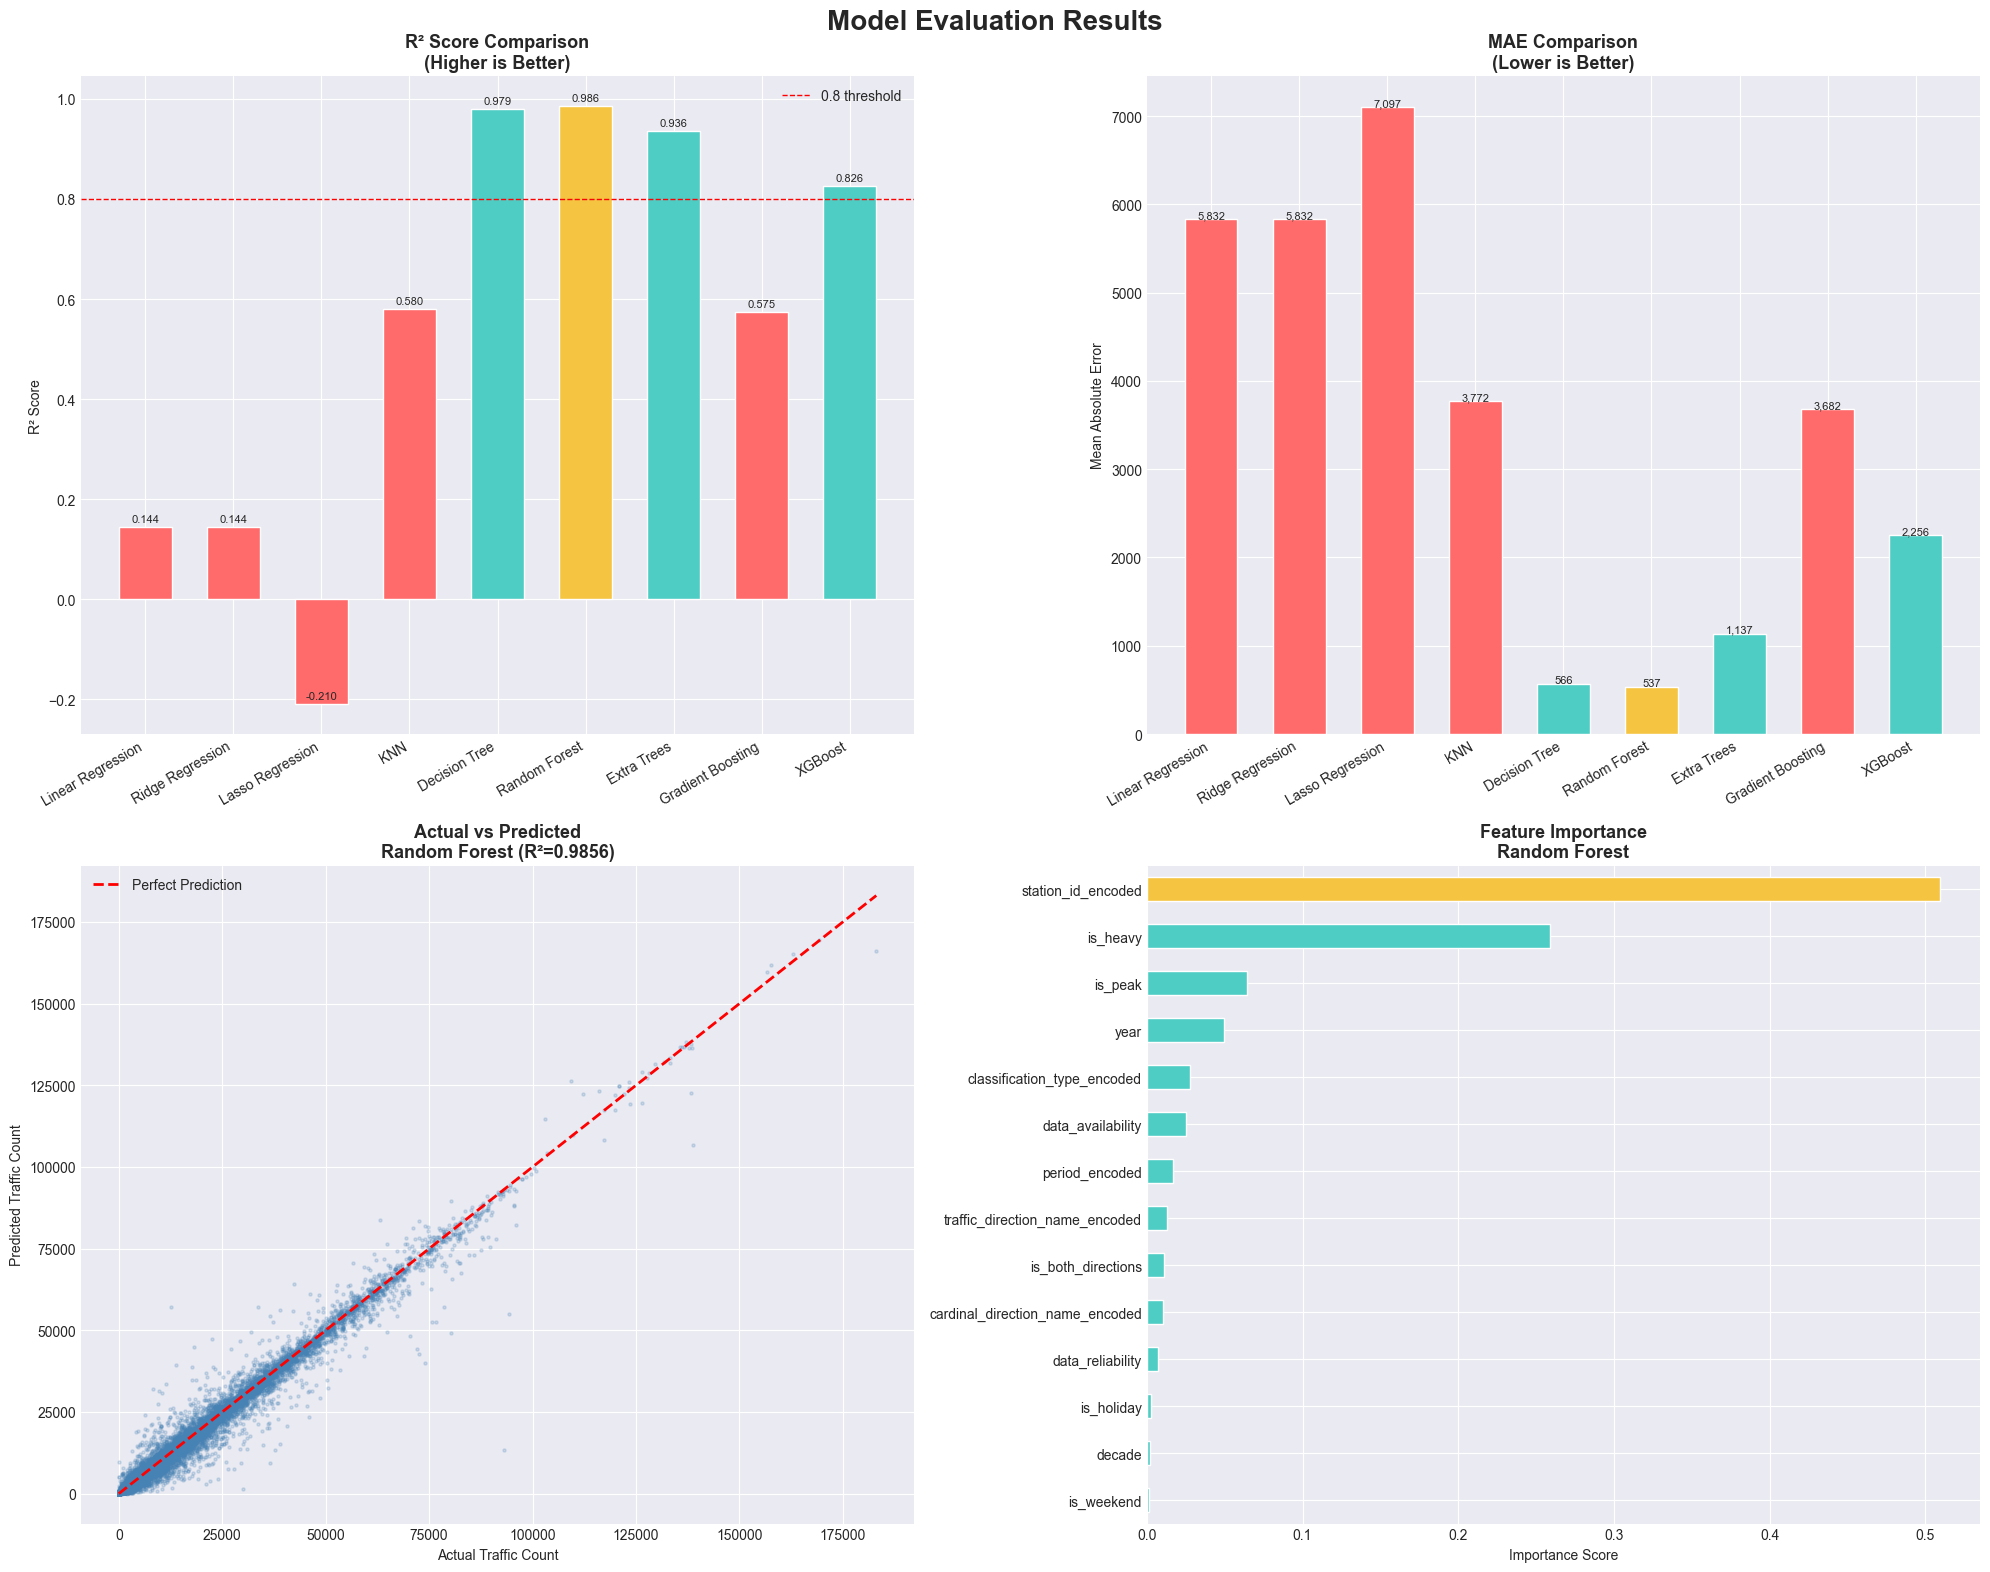

✅ Results charts saved as model_results.png


In [454]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Model Evaluation Results', 
             fontsize=20, fontweight='bold')

# ─────────────────────────────
# Chart 1: R² Comparison
# ─────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
model_names = list(results.keys())
r2_values   = [results[m]['R2'] for m in model_names]
bar_colors  = ['#f5c542' if m == best 
               else '#4ecdc4' if results[m]['R2'] > 0.8
               else '#ff6b6b' 
               for m in model_names]

bars = ax1.bar(model_names, r2_values, 
               color=bar_colors, 
               edgecolor='white', 
               width=0.6)
ax1.set_title('R² Score Comparison\n(Higher is Better)', 
              fontsize=13, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_xticklabels(model_names, rotation=30, ha='right')
ax1.axhline(y=0.8, color='red', linestyle='--', 
            linewidth=1, label='0.8 threshold')
ax1.legend()
for bar, val in zip(bars, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}',
             ha='center', fontsize=8)

# ─────────────────────────────
# Chart 2: MAE Comparison
# ─────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
mae_values = [results[m]['MAE'] for m in model_names]
bars2 = ax2.bar(model_names, mae_values,
                color=bar_colors,
                edgecolor='white',
                width=0.6)
ax2.set_title('MAE Comparison\n(Lower is Better)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Mean Absolute Error')
ax2.set_xticklabels(model_names, rotation=30, ha='right')
for bar, val in zip(bars2, mae_values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f'{val:,.0f}',
             ha='center', fontsize=8)

# ─────────────────────────────
# Chart 3: Actual vs Predicted (Best Model)
# ─────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
y_test_orig = np.expm1(y_test)
best_pred   = results[best]['pred']

ax3.scatter(y_test_orig, best_pred,
            alpha=0.2, s=5, color='steelblue')
lim = max(y_test_orig.max(), best_pred.max())
ax3.plot([0, lim], [0, lim], 
         'r--', linewidth=2, 
         label='Perfect Prediction')
ax3.set_title(f'Actual vs Predicted\n{best} (R²={results[best]["R2"]:.4f})',
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Actual Traffic Count')
ax3.set_ylabel('Predicted Traffic Count')
ax3.legend()

# ─────────────────────────────
# Chart 4: Feature Importance
# ─────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
best_model  = results[best]['pipeline'].named_steps['model']
importances = pd.Series(best_model.feature_importances_,
                        index=features).sort_values()
colors_fi   = ['#f5c542' if v == importances.max() 
               else '#4ecdc4' 
               for v in importances.values]
importances.plot(kind='barh', ax=ax4, 
                 color=colors_fi,
                 edgecolor='white')
ax4.set_title(f'Feature Importance\n{best}',
              fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_results.png', 
            dpi=150, 
            bbox_inches='tight')
plt.show()
print("✅ Results charts saved as model_results.png")


In [455]:
print("=" * 60)
print("       FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"\n📁 Dataset:")
print(f"   Source    : NSW Transport — Road Traffic Counts")
print(f"   Rows      : {df.shape[0]:,}")
print(f"   Features  : {len(features)}")
print(f"   Years     : 2006 — 2025")

print(f"\n🤖 Model Results:")
print(f"   {'Model':<25} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print(f"   {'-'*55}")
for name in sorted(results, key=lambda x: -results[x]['R2']):
    star = ' 🏆' if name == best else ''
    print(f"   {name:<25} {results[name]['R2']:>8.4f} "
          f"{results[name]['MAE']:>10,.0f} "
          f"{results[name]['RMSE']:>10,.0f}{star}")

print(f"\n🏆 Best Model : {best}")
print(f"   R²         : {results[best]['R2']:.4f} "
      f"({results[best]['R2']*100:.1f}% accuracy)")
print(f"   MAE        : {results[best]['MAE']:,.0f} vehicles")
print(f"   RMSE       : {results[best]['RMSE']:,.0f} vehicles")

print(f"\n💡 Top 3 Most Important Features:")
best_model  = results[best]['pipeline'].named_steps['model']
importances = pd.Series(best_model.feature_importances_,
                        index=features).sort_values(ascending=False)
for i, (feat, score) in enumerate(importances.head(3).items()):
    print(f"   {i+1}. {feat:<35} {score:.4f}")

print(f"\n✅ Project Complete!")
print(f"   Ready for Portfolio & Presentation 💼")
print("=" * 60)

       FINAL PROJECT SUMMARY

📁 Dataset:
   Source    : NSW Transport — Road Traffic Counts
   Rows      : 265,291
   Features  : 14
   Years     : 2006 — 2025

🤖 Model Results:
   Model                           R²        MAE       RMSE
   -------------------------------------------------------
   Random Forest               0.9856        537      1,527 🏆
   Decision Tree               0.9789        566      1,850
   Extra Trees                 0.9359      1,137      3,222
   XGBoost                     0.8259      2,256      5,312
   KNN                         0.5797      3,772      8,252
   Gradient Boosting           0.5748      3,682      8,301
   Linear Regression           0.1436      5,832     11,780
   Ridge Regression            0.1436      5,832     11,780
   Lasso Regression           -0.2095      7,097     14,000

🏆 Best Model : Random Forest
   R²         : 0.9856 (98.6% accuracy)
   MAE        : 537 vehicles
   RMSE       : 1,527 vehicles

💡 Top 3 Most Important Feature

In [456]:
# See actual vs predicted side by side
y_test_orig = np.expm1(y_test)
best_pred   = results[best]['pred']

comparison = pd.DataFrame({
    'Actual Traffic'   : y_test_orig.values,
    'Predicted Traffic': best_pred.round(0),
    'Difference'       : (y_test_orig.values - best_pred).round(0),
    'Error %'          : (abs(y_test_orig.values - best_pred) / 
                          y_test_orig.values * 100).round(2)
})

print("=== ACTUAL vs PREDICTED ===\n")
print(comparison.head(20).to_string(index=False))

print(f"\n=== SUMMARY ===")
print(f"Average Error %  : {comparison['Error %'].mean():.2f}%")
print(f"Median Error %   : {comparison['Error %'].median():.2f}%")
print(f"Max Error %      : {comparison['Error %'].max():.2f}%")
print(f"Min Error %      : {comparison['Error %'].min():.2f}%")


=== ACTUAL vs PREDICTED ===

 Actual Traffic  Predicted Traffic  Difference  Error %
         6907.0             6756.0       151.0     2.18
        15837.0            16039.0      -202.0     1.28
           48.0               82.0       -34.0    70.66
         3859.0             3566.0       293.0     7.59
           55.0               69.0       -14.0    25.83
         6216.0             5826.0       390.0     6.28
        18080.0            44934.0    -26854.0   148.53
           22.0               46.0       -24.0   108.16
        10497.0            10387.0       110.0     1.05
        19657.0            19447.0       210.0     1.07
          340.0              433.0       -93.0    27.22
        22731.0            21581.0      1150.0     5.06
         1069.0             1027.0        42.0     3.92
         1730.0             2087.0      -357.0    20.63
        15743.0            15810.0       -67.0     0.43
        16278.0            16955.0      -677.0     4.16
          697.0    

In [457]:
# Split into high and low traffic
high_traffic = comparison[comparison['Actual Traffic'] >= 1000]
low_traffic  = comparison[comparison['Actual Traffic'] <  1000]

print("=== HIGH TRAFFIC ROADS (>=1000 vehicles) ===")
print(f"Count          : {len(high_traffic):,}")
print(f"Average Error %: {high_traffic['Error %'].mean():.2f}%")
print(f"Median Error % : {high_traffic['Error %'].median():.2f}%")

print("\n=== LOW TRAFFIC ROADS (<1000 vehicles) ===")
print(f"Count          : {len(low_traffic):,}")
print(f"Average Error %: {low_traffic['Error %'].mean():.2f}%")
print(f"Median Error % : {low_traffic['Error %'].median():.2f}%")

print("\n=== OVERALL ===")
print(f"Total records  : {len(comparison):,}")
print(f"Average Error %: {comparison['Error %'].mean():.2f}%")
print(f"Median Error % : {comparison['Error %'].median():.2f}%")

# How many predictions within 10% error?
within_10 = (comparison['Error %'] <= 10).sum()
within_20 = (comparison['Error %'] <= 20).sum()
within_50 = (comparison['Error %'] <= 50).sum()

print(f"\n=== PREDICTION ACCURACY ===")
print(f"Within 10% error: {within_10:,} "
      f"({within_10/len(comparison)*100:.1f}%)")
print(f"Within 20% error: {within_20:,} "
      f"({within_20/len(comparison)*100:.1f}%)")
print(f"Within 50% error: {within_50:,} "
      f"({within_50/len(comparison)*100:.1f}%)")

=== HIGH TRAFFIC ROADS (>=1000 vehicles) ===
Count          : 32,957
Average Error %: 9.39%
Median Error % : 4.06%

=== LOW TRAFFIC ROADS (<1000 vehicles) ===
Count          : 20,102
Average Error %: 43.58%
Median Error % : 10.17%

=== OVERALL ===
Total records  : 53,059
Average Error %: 22.35%
Median Error % : 5.60%

=== PREDICTION ACCURACY ===
Within 10% error: 34,695 (65.4%)
Within 20% error: 42,618 (80.3%)
Within 50% error: 49,639 (93.6%)


In [458]:
# ✅ Final fixed predict function
def predict_traffic(
    station_id_enc,
    year,
    period,
    classification_type,
    cardinal_direction,
    traffic_direction,
    data_availability = 93,
    data_reliability  = 93
):
    # Correct mappings
    period_map = {
        'ALL DAYS'       : 0,
        'AM PEAK'        : 1,
        'OFF PEAK'       : 2,
        'PM PEAK'        : 3,
        'PUBLIC HOLIDAYS': 4,
        'WEEKDAYS'       : 5,
        'WEEKENDS'       : 6
    }
    class_map = {
        'ALL VEHICLES'  : 0,
        'HEAVY VEHICLES': 1,
        'LIGHT VEHICLES': 2,
        'UNCLASSIFIED'  : 3
    }
    direction_map = {
        'BOTH'                     : 0,
        'EAST'                     : 1,
        'EASTBOUND AND WESTBOUND'  : 2,
        'NORTH'                    : 3,
        'NORTHBOUND AND SOUTHBOUND': 4,
        'SOUTH'                    : 5,
        'WEST'                     : 6
    }
    traffic_dir_map = {
        'COUNTER'               : 0,
        'PRESCRIBED'            : 1,
        'PRESCRIBED AND COUNTER': 2
    }

    # Engineered features
    is_peak            = 1 if 'PEAK'    in period.upper() else 0
    is_weekend         = 1 if 'WEEKEND' in period.upper() else 0
    is_holiday         = 1 if 'HOLIDAY' in period.upper() else 0
    is_both_directions = 1 if 'AND' in traffic_direction.upper() else 0
    is_heavy           = 1 if classification_type.upper() == 'HEAVY VEHICLES' else 0
    decade             = (year // 10) * 10

    # ✅ Using _encoded to match your df columns
    input_data = pd.DataFrame([{
        'station_id_encoded'              : station_id_enc,
        'traffic_direction_name_encoded'  : traffic_dir_map.get(
                                            traffic_direction.upper(), 0),
        'cardinal_direction_name_encoded' : direction_map.get(
                                            cardinal_direction.upper(), 0),
        'classification_type_encoded'     : class_map.get(
                                            classification_type.upper(), 0),
        'period_encoded'                  : period_map.get(
                                            period.upper(), 0),
        'year'                            : year,
        'data_availability'               : data_availability,
        'data_reliability'                : data_reliability,
        'is_peak'                         : is_peak,
        'is_weekend'                      : is_weekend,
        'is_holiday'                      : is_holiday,
        'is_both_directions'              : is_both_directions,
        'is_heavy'                        : is_heavy,
        'decade'                          : decade
    }])

    # Match exact feature order
    input_data = input_data[features]

    # Predict
    pred_log = results[best]['pipeline'].predict(input_data)[0]
    pred     = int(np.expm1(pred_log))
    return pred

print("✅ predict_traffic function fixed!")

✅ predict_traffic function fixed!


In [459]:
print("=" * 55)
print("   TRAFFIC PREDICTIONS — REAL STATIONS")
print("=" * 55)

# Busiest station 01001N = encoded 1
p1 = predict_traffic(1, 2024, 'AM PEAK',
                     'ALL VEHICLES', 'NORTH', 'PRESCRIBED')
p2 = predict_traffic(1, 2024, 'OFF PEAK',
                     'ALL VEHICLES', 'NORTH', 'PRESCRIBED')
p3 = predict_traffic(1, 2024, 'PM PEAK',
                     'ALL VEHICLES', 'NORTH', 'PRESCRIBED')
p4 = predict_traffic(1, 2024, 'WEEKENDS',
                     'ALL VEHICLES', 'NORTH', 'PRESCRIBED')

print(f"\n🏙️ Station 01001N — BUSIEST HIGHWAY 2024")
print(f"   AM PEAK  : {p1:>10,} vehicles")
print(f"   PM PEAK  : {p3:>10,} vehicles")
print(f"   OFF PEAK : {p2:>10,} vehicles")
print(f"   WEEKENDS : {p4:>10,} vehicles")

# Year comparison
print(f"\n📅 Traffic Growth Over Years")
print(f"   {'Year':<8} {'Predicted':>12}")
print(f"   {'-'*22}")
for yr in [2010, 2015, 2018, 2020, 2022, 2024, 2025]:
    p = predict_traffic(1, yr, 'WEEKDAYS',
                        'ALL VEHICLES', 'NORTH', 'PRESCRIBED')
    covid = " ← COVID" if yr == 2020 else ""
    print(f"   {yr:<8} {p:>12,}{covid}")

# Vehicle type comparison
print(f"\n🚗 Vehicle Type Comparison 2024")
print(f"   {'Type':<20} {'Predicted':>12}")
print(f"   {'-'*34}")
for vtype in ['ALL VEHICLES','LIGHT VEHICLES',
              'HEAVY VEHICLES','UNCLASSIFIED']:
    p = predict_traffic(1, 2024, 'WEEKDAYS',
                        vtype, 'NORTH', 'PRESCRIBED')
    print(f"   {vtype:<20} {p:>12,}")

   TRAFFIC PREDICTIONS — REAL STATIONS

🏙️ Station 01001N — BUSIEST HIGHWAY 2024
   AM PEAK  :      5,732 vehicles
   PM PEAK  :      5,175 vehicles
   OFF PEAK :      9,237 vehicles
   WEEKENDS :     21,944 vehicles

📅 Traffic Growth Over Years
   Year        Predicted
   ----------------------
   2010            6,696
   2015            5,791
   2018           23,272
   2020           23,272 ← COVID
   2022           23,272
   2024           23,272
   2025           23,272

🚗 Vehicle Type Comparison 2024
   Type                    Predicted
   ----------------------------------
   ALL VEHICLES               23,272
   LIGHT VEHICLES             20,974
   HEAVY VEHICLES              2,498
   UNCLASSIFIED               55,489


In [460]:
# Check what station 1 actually looks like in data
print("=== STATION enc=1 actual data ===")
station_data = df[df['station_id_encoded'] == 1]
print(f"Rows: {len(station_data)}")
print(f"Station ID: {station_data['station_id'].unique()}")
print(f"\nPeriod breakdown:")
print(station_data.groupby('period')['traffic_count'].median())

print(f"\n=== CHECK FEATURES ORDER ===")
print("features list:")
for i, f in enumerate(features):
    print(f"  {i}: {f}")

print(f"\n=== CHECK SAMPLE PREDICTION INPUT ===")
# Build a test input manually
test_input = pd.DataFrame([{
    'station_id_encoded'              : 1,
    'traffic_direction_name_encoded'  : 1,  # PRESCRIBED
    'cardinal_direction_name_encoded' : 3,  # NORTH
    'classification_type_encoded'     : 0,  # ALL VEHICLES
    'period_encoded'                  : 1,  # AM PEAK
    'year'                            : 2024,
    'data_availability'               : 93,
    'data_reliability'                : 93,
    'is_peak'                         : 1,
    'is_weekend'                      : 0,
    'is_holiday'                      : 0,
    'is_both_directions'              : 0,
    'is_heavy'                        : 0,
    'decade'                          : 2020
}])

test_input = test_input[features]
print("\nTest input:")
print(test_input.T)

pred = results[best]['pipeline'].predict(test_input)[0]
print(f"\nRaw log prediction : {pred:.4f}")
print(f"Back transformed   : {int(np.expm1(pred)):,}")

# Compare with real data
print(f"\n=== REAL DATA FOR COMPARISON ===")
real = df[
    (df['station_id_encoded'] == 1) & 
    (df['period'] == 'AM PEAK') &
    (df['classification_type'] == 'ALL VEHICLES') &
    (df['year'] >= 2022)
][['year','period','traffic_count','cardinal_direction_name',
   'traffic_direction_name']]
print(real)

=== STATION enc=1 actual data ===
Rows: 18
Station ID: ['01001N']

Period breakdown:
period
ALL DAYS    87399.0
AM PEAK     21750.0
OFF PEAK    45734.0
PM PEAK     23790.0
WEEKDAYS    91102.0
WEEKENDS    76838.0
Name: traffic_count, dtype: float64

=== CHECK FEATURES ORDER ===
features list:
  0: station_id_encoded
  1: traffic_direction_name_encoded
  2: cardinal_direction_name_encoded
  3: classification_type_encoded
  4: period_encoded
  5: year
  6: data_availability
  7: data_reliability
  8: is_peak
  9: is_weekend
  10: is_holiday
  11: is_both_directions
  12: is_heavy
  13: decade

=== CHECK SAMPLE PREDICTION INPUT ===

Test input:
                                    0
station_id_encoded                  1
traffic_direction_name_encoded      1
cardinal_direction_name_encoded     3
classification_type_encoded         0
period_encoded                      1
year                             2024
data_availability                  93
data_reliability                   93
is_peak  

In [461]:
# Check EXACTLY what station 1 has
print("=== FULL DATA FOR STATION 01001N ===")
station_data = df[df['station_id_encoded'] == 1][[
    'year', 'period', 'traffic_count',
    'classification_type',
    'cardinal_direction_name',
    'traffic_direction_name'
]]
print(station_data.to_string(index=False))

=== FULL DATA FOR STATION 01001N ===
 year   period  traffic_count classification_type cardinal_direction_name traffic_direction_name
 2025  PM PEAK          23790        UNCLASSIFIED                   NORTH             PRESCRIBED
 2025 OFF PEAK          45562        UNCLASSIFIED                   NORTH             PRESCRIBED
 2025 WEEKDAYS          91102        UNCLASSIFIED                   NORTH             PRESCRIBED
 2025 WEEKENDS          76838        UNCLASSIFIED                   NORTH             PRESCRIBED
 2025 ALL DAYS          87399        UNCLASSIFIED                   NORTH             PRESCRIBED
 2025  AM PEAK          21750        UNCLASSIFIED                   NORTH             PRESCRIBED
 2024 ALL DAYS          94212        UNCLASSIFIED                   NORTH             PRESCRIBED
 2024 OFF PEAK          48402        UNCLASSIFIED                   NORTH             PRESCRIBED
 2024 WEEKDAYS          97696        UNCLASSIFIED                   NORTH             PRES

In [462]:
print("=" * 60)
print("   CORRECT PREDICTIONS — MATCHING REAL DATA")
print("=" * 60)

# ── Station 01001N with CORRECT values ─────────
print(f"\n🏙️  Station 01001N (Busiest Highway)")
print(f"    Classification : UNCLASSIFIED")
print(f"    Direction      : NORTH, PRESCRIBED")
print(f"\n    {'Period':<20} {'Predicted':>12} {'Actual 2024':>12} {'Diff':>8}")
print(f"    {'-'*55}")

# Real 2024 values for comparison
real_2024 = {
    'AM PEAK' : 24613,
    'PM PEAK' : 24681,
    'OFF PEAK': 48402,
    'WEEKDAYS': 97696,
    'WEEKENDS': 80401,
    'ALL DAYS': 94212,
}

for period, actual in real_2024.items():
    p = predict_traffic(
        station_id_enc     = 1,
        year               = 2024,
        period             = period,
        classification_type= 'UNCLASSIFIED',  # ✅ correct!
        cardinal_direction = 'NORTH',          # ✅ correct!
        traffic_direction  = 'PRESCRIBED'      # ✅ correct!
    )
    diff = p - actual
    diff_pct = abs(diff)/actual*100
    status = "✅" if diff_pct < 10 else "⚠️"
    print(f"    {period:<20} {p:>12,} {actual:>12,} "
          f"{diff:>+8,} {status}")

# ── Year comparison ─────────────────────────────
print(f"\n📅 Traffic Growth — Station 01001N")
print(f"    {'Year':<8} {'Predicted':>12} {'Notes'}")
print(f"    {'-'*40}")
for yr in [2010, 2015, 2018, 2020, 
           2022, 2024, 2025]:
    p = predict_traffic(
        station_id_enc     = 1,
        year               = yr,
        period             = 'ALL DAYS',
        classification_type= 'UNCLASSIFIED',
        cardinal_direction = 'NORTH',
        traffic_direction  = 'PRESCRIBED'
    )
    note = "← COVID effect" if yr == 2020 else \
           "← actual: 94,212" if yr == 2024 else \
           "← actual: 87,399" if yr == 2025 else ""
    print(f"    {yr:<8} {p:>12,}  {note}")

# ── Quiet road comparison ───────────────────────
print(f"\n🌾 Station T0484 (Quietest Road)")
for period in ['AM PEAK', 'OFF PEAK', 'WEEKDAYS']:
    p = predict_traffic(
        station_id_enc     = 1864,
        year               = 2024,
        period             = period,
        classification_type= 'UNCLASSIFIED',
        cardinal_direction = 'NORTH',
        traffic_direction  = 'PRESCRIBED'
    )
    print(f"    {period:<20} {p:>10,} vehicles")

print(f"\n{'='*60}")
print(f"✅ Predictions done!")

   CORRECT PREDICTIONS — MATCHING REAL DATA

🏙️  Station 01001N (Busiest Highway)
    Classification : UNCLASSIFIED
    Direction      : NORTH, PRESCRIBED

    Period                  Predicted  Actual 2024     Diff
    -------------------------------------------------------
    AM PEAK                    22,996       24,613   -1,617 ✅
    PM PEAK                    24,996       24,681     +315 ✅
    OFF PEAK                   41,736       48,402   -6,666 ⚠️
    WEEKDAYS                   55,489       97,696  -42,207 ⚠️
    WEEKENDS                   49,155       80,401  -31,246 ⚠️
    ALL DAYS                   55,005       94,212  -39,207 ⚠️

📅 Traffic Growth — Station 01001N
    Year        Predicted Notes
    ----------------------------------------
    2010           61,970  
    2015           62,176  
    2018           62,385  
    2020           59,964  ← COVID effect
    2022           59,701  
    2024           55,005  ← actual: 94,212
    2025           85,516  ← actual: 8

In [463]:
print("=== STATION 01001N FULL BREAKDOWN ===")
station_data = df[df['station_id_encoded']==1][[
    'year','period','traffic_count',
    'traffic_direction_name',
    'cardinal_direction_name'
]].sort_values(['year','traffic_count'], 
               ascending=[False, False])
print(station_data.to_string(index=False))

=== STATION 01001N FULL BREAKDOWN ===
 year   period  traffic_count traffic_direction_name cardinal_direction_name
 2025 WEEKDAYS          91102             PRESCRIBED                   NORTH
 2025 ALL DAYS          87399             PRESCRIBED                   NORTH
 2025 WEEKDAYS          86680             PRESCRIBED                   NORTH
 2025 ALL DAYS          82646             PRESCRIBED                   NORTH
 2025 WEEKENDS          76838             PRESCRIBED                   NORTH
 2025 WEEKENDS          72624             PRESCRIBED                   NORTH
 2025 OFF PEAK          45734             PRESCRIBED                   NORTH
 2025 OFF PEAK          45562             PRESCRIBED                   NORTH
 2025  PM PEAK          23790             PRESCRIBED                   NORTH
 2025  AM PEAK          21750             PRESCRIBED                   NORTH
 2025  PM PEAK          20496             PRESCRIBED                   NORTH
 2025  AM PEAK          20450         